# CVRPLIB-X：Augmented Gap 逐实例对比（ICAM / OMNI / ReLD）

目标：用逐实例 **Augmented Gap(%)**（越小越好）证明：**不存在一种方法在所有实例上都 dominate 其它方法**。

日志文件：
- `icam.txt`
- `omni.txt`
- `reld.txt`

说明：如果某个日志为空/解析不到实例，本 notebook 会显式提示，并在“可用方法子集”上继续做分析（但无法完成三方法结论）。


In [10]:
from __future__ import annotations

from pathlib import Path
import re
from collections import defaultdict
from html import escape
import statistics as stats

try:
    import numpy as np
except Exception:
    np = None

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

try:
    from IPython.display import display, HTML
except Exception:
    display = None
    HTML = None


def find_repo_root(start: Path, max_up: int = 8) -> Path:
    p = start.resolve()
    for _ in range(max_up + 1):
        if (p / "benchmarks").exists() and (p / "EasyNCO").exists():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise RuntimeError("Cannot find repo root (expected both benchmarks/ and EasyNCO/)")


NUM = r"[+-]?(?:\d+\.\d+|\d+)(?:[eE][+-]?\d+)?"
EVAL_LINE_RE = re.compile(
    rf"\[(?P<date>\d{{4}}-\d{{2}}-\d{{2}} \d{{2}}:\d{{2}}:\d{{2}}),(?P<ms>\d{{3}})\].*?"
    rf"Eval ==> Problem\[(?P<problem>[^\]]+)\], Size\[(?P<size>\d+)\], Name\[(?P<name>[^\]]+)\].*?"
    rf"Score: (?P<score>{NUM}), Augmented Score: (?P<aug_score>{NUM}), "
    rf"Gap: (?P<gap>{NUM})%, Augmented Gap: (?P<aug_gap>{NUM})%"
)


def parse_eval_log_to_map(path: Path) -> tuple[dict[str, dict], list[str]]:
    """Return (inst->record, duplicates). Keep the last occurrence if duplicated."""
    text = path.read_text(encoding="utf-8", errors="ignore")
    out: dict[str, dict] = {}
    dup: list[str] = []
    for m in EVAL_LINE_RE.finditer(text):
        inst = m.group("name").strip()
        rec = {
            "instance": inst,
            "problem": m.group("problem").strip(),
            "n": int(m.group("size")),
            "aug_gap": float(m.group("aug_gap")),
        }
        if inst in out:
            dup.append(inst)
        out[inst] = rec
    return out, dup


def display_table(rows, headers, title: str | None = None, max_rows: int = 50):
    if title:
        print("\n" + title)
    rows = list(rows)
    show = rows[:max_rows]
    truncated = len(rows) > max_rows
    if display is None or HTML is None:
        print("\t".join(headers))
        for r in show:
            print("\t".join(str(r.get(h, "")) for h in headers))
        if truncated:
            print(f"... (仅展示前 {max_rows} 行，共 {len(rows)} 行)")
        return
    html = ["<table style='border-collapse:collapse; font-family:monospace; font-size:12px'>"]
    html.append("<thead><tr>")
    for h in headers:
        html.append(
            "<th style='border:1px solid #ccc; padding:4px; text-align:left'>"
            + escape(str(h))
            + "</th>"
        )
    html.append("</tr></thead><tbody>")
    for r in show:
        html.append("<tr>")
        for h in headers:
            html.append(
                "<td style='border:1px solid #ccc; padding:4px'>"
                + escape(str(r.get(h, "")))
                + "</td>"
            )
        html.append("</tr>")
    html.append("</tbody></table>")
    if truncated:
        html.append(
            f"<div style='color:#666; font-size:12px'>(仅展示前 {max_rows} 行，共 {len(rows)} 行)</div>"
        )
    display(HTML("".join(html)))


def bucket_n(n: int) -> str:
    if n <= 200:
        return "<=200"
    if n <= 500:
        return "201-500"
    if n <= 800:
        return "501-800"
    return ">800"


def pairwise_counts(a_map: dict[str, float], b_map: dict[str, float], instances: list[str], eps: float = 1e-9):
    lt = eq = gt = 0
    deltas = []
    for inst in instances:
        da = a_map[inst]
        db = b_map[inst]
        d = da - db
        deltas.append(d)
        if d < -eps:
            lt += 1
        elif d > eps:
            gt += 1
        else:
            eq += 1
    return {
        "A_better": lt,
        "tie": eq,
        "A_worse": gt,
        "mean(A-B)": stats.mean(deltas) if deltas else None,
        "median(A-B)": stats.median(deltas) if deltas else None,
        "min(A-B)": min(deltas) if deltas else None,
        "max(A-B)": max(deltas) if deltas else None,
    }


In [11]:
# 1) 定位并读取 3 个日志
repo_root = find_repo_root(Path.cwd())
log_dir = repo_root / "benchmarks" / "results" / "cvrplib_x"
runs = {
    "icam": log_dir / "icam.txt",
    "omni": log_dir / "omni.txt",
    "reld": log_dir / "reld.txt",
}

run_rec = {}
run_gap = {}
run_dup = {}

print("File stats:")
for name, path in runs.items():
    size = path.stat().st_size if path.exists() else None
    print(f"- {name}: {path.name}  bytes={size}")

print("\nParsed instances:")
for name, path in runs.items():
    rec_map, dup = parse_eval_log_to_map(path) if path.exists() else ({}, [])
    run_rec[name] = rec_map
    run_dup[name] = dup
    run_gap[name] = {k: v["aug_gap"] for k, v in rec_map.items()}
    print(f"{name:5s}: {len(rec_map)} instances (dups={len(dup)})")

available = [k for k, v in run_rec.items() if len(v) > 0]
print("\navailable methods:", available)
if len(available) < 3:
    print("WARNING: 少于 3 个有效日志，无法完成三方法 non-dominance 结论。请先补全缺失日志（例如 reld.txt）。")


File stats:
- icam: icam.txt  bytes=85826
- omni: omni.txt  bytes=86417
- reld: reld.txt  bytes=85846

Parsed instances:
icam : 100 instances (dups=0)
omni : 100 instances (dups=0)
reld : 100 instances (dups=0)

available methods: ['icam', 'omni', 'reld']


In [12]:
# 2) 共同实例集合（以 available 为准）
EPS = 1e-9
methods = available
inst_sets = {k: set(run_rec[k].keys()) for k in methods}
common = set.intersection(*inst_sets.values()) if inst_sets else set()
common_sorted = sorted(common)

print("common instances:", len(common_sorted))
for m in methods:
    missing = sorted(common - set(run_rec[m].keys()))
    extra = sorted(set(run_rec[m].keys()) - common)
    if missing or extra:
        print(m, "missing", len(missing), "extra", len(extra))

# 取 n（以第一个可用方法为参考）
inst_n = {}
if methods:
    ref = methods[0]
    inst_n = {inst: run_rec[ref][inst]["n"] for inst in common_sorted}
    ns = sorted(set(inst_n.values()))
    if ns:
        print("n unique:", len(ns), "min", min(ns), "max", max(ns))


common instances: 100
n unique: 100 min 100 max 1000


In [19]:
# 3) 逐实例对比表（Augmented Gap + winner）
rows = []
for inst in common_sorted:
    vals = {m: run_gap[m][inst] for m in methods}
    best = min(vals.values())
    winners = [m for m, v in vals.items() if abs(v - best) <= EPS]
    row = {"instance": inst, "n": inst_n.get(inst)}
    row.update(vals)
    row["winner"] = ",".join(winners)
    rows.append(row)

rows_sorted = sorted(rows, key=lambda r: (r["n"] if r["n"] is not None else 10**9, r["instance"]))
display_table(rows_sorted, ["instance", "n"] + methods + ["winner"], title="逐实例 Augmented Gap(%)（越小越好）", max_rows=100)



逐实例 Augmented Gap(%)（越小越好）


instance,n,icam,omni,reld,winner
X-n101-k25,100,6.2013,6.2412,2.5378,reld
X-n106-k14,105,2.7236,2.6591,1.7342,reld
X-n110-k13,109,0.8015,2.0239,1.3633,icam
X-n115-k10,114,6.629,3.5773,2.2885,reld
X-n120-k6,119,2.4377,5.6331,2.2865,reld
X-n125-k30,124,4.73,6.0048,3.7697,reld
X-n129-k18,128,1.3165,3.5764,1.4657,icam
X-n134-k13,133,5.0843,3.7834,4.2899,omni
X-n139-k10,138,1.5305,3.1347,2.0772,icam
X-n143-k7,142,1.7834,5.7452,2.8954,icam


In [14]:
# 4) 方法级描述统计
def describe(vals: list[float]) -> dict:
    qs = [0.05, 0.25, 0.5, 0.75, 0.95]
    out = {
        "mean": stats.mean(vals),
        "median": stats.median(vals),
        "stdev": stats.pstdev(vals),
        "min": min(vals),
        "max": max(vals),
    }
    if np is not None:
        arr = np.array(vals, dtype=float)
        for q in qs:
            out[f"q{int(q*100):02d}"] = float(np.quantile(arr, q))
    return out

desc_rows = []
for m in methods:
    vals = [run_gap[m][inst] for inst in common_sorted]
    d = describe(vals)
    desc_rows.append({"method": m, **{k: round(v, 6) for k, v in d.items()}})
display_table(
    desc_rows,
    ["method", "mean", "median", "stdev", "min", "q05", "q25", "q50", "q75", "q95", "max"],
    title="方法级 gap 分布摘要",
)



方法级 gap 分布摘要


method,mean,median,stdev,min,q05,q25,q50,q75,q95,max
icam,4.3379,3.8245,2.532079,0.7441,1.5262,2.71575,3.8245,5.075075,10.341075,15.3871
omni,6.093793,6.0967,2.638689,1.3688,2.476615,4.07405,6.0967,7.599225,9.61045,18.3529
reld,4.021363,3.8257,1.703302,0.7294,1.552435,2.857,3.8257,4.99385,7.50885,9.2694


In [15]:
# 5) Win 统计（strict / tie）+ tie-size 分布
win_strict = defaultdict(int)
win_tie = defaultdict(int)
tie_size_hist = defaultdict(int)
strict_wins = defaultdict(list)

for r in rows:
    inst = r["instance"]
    vals = [(m, r[m]) for m in methods]
    best = min(v for _, v in vals)
    winners = [m for m, v in vals if abs(v - best) <= EPS]
    if len(winners) == 1:
        win_strict[winners[0]] += 1
        strict_wins[winners[0]].append(inst)
    else:
        tie_size_hist[len(winners)] += 1
        for w in winners:
            win_tie[w] += 1

summary = []
for m in methods:
    summary.append(
        {
            "method": m,
            "strict_win": win_strict[m],
            "tie_win": win_tie[m],
            "win_including_ties": win_strict[m] + win_tie[m],
        }
    )
summary = sorted(summary, key=lambda x: (-x["win_including_ties"], -x["strict_win"]))
display_table(summary, ["method", "strict_win", "tie_win", "win_including_ties"], title="Win 次数统计")

print("\nTie-size histogram:", dict(sorted(tie_size_hist.items())))
for m in methods:
    print(f"{m} strict wins ({len(strict_wins[m])}):", ", ".join(sorted(strict_wins[m])[:15]), "..." if len(strict_wins[m]) > 15 else "")



Win 次数统计


method,strict_win,tie_win,win_including_ties
icam,46,0,46
reld,46,0,46
omni,8,0,8



Tie-size histogram: {}
icam strict wins (46): X-n1001-k43, X-n110-k13, X-n129-k18, X-n139-k10, X-n143-k7, X-n181-k23, X-n209-k16, X-n223-k34, X-n233-k16, X-n251-k28, X-n261-k13, X-n270-k35, X-n275-k28, X-n298-k31, X-n303-k21 ...
omni strict wins (8): X-n134-k13, X-n157-k13, X-n186-k15, X-n214-k11, X-n280-k17, X-n284-k15, X-n327-k20, X-n573-k30 
reld strict wins (46): X-n101-k25, X-n106-k14, X-n115-k10, X-n120-k6, X-n125-k30, X-n148-k46, X-n153-k22, X-n162-k11, X-n167-k10, X-n172-k51, X-n176-k26, X-n190-k8, X-n195-k51, X-n200-k36, X-n204-k19 ...


In [16]:
# 6) 两两对比 + dominance 检查（A dominates B <=> A 从不更差且至少一次更好）
pair_rows = []
for a in methods:
    for b in methods:
        if a == b:
            continue
        res = pairwise_counts(run_gap[a], run_gap[b], common_sorted, eps=EPS)
        dominates = (res["A_worse"] == 0) and (res["A_better"] > 0)
        pair_rows.append(
            {
                "A": a,
                "B": b,
                "A_better": res["A_better"],
                "tie": res["tie"],
                "A_worse": res["A_worse"],
                "mean(A-B)": round(res["mean(A-B)"], 6),
                "median(A-B)": round(res["median(A-B)"], 6),
                "A_dominates_B": dominates,
            }
        )
pair_rows = sorted(pair_rows, key=lambda r: (r["A"], r["B"]))
display_table(
    pair_rows,
    ["A", "B", "A_better", "tie", "A_worse", "mean(A-B)", "median(A-B)", "A_dominates_B"],
    title="两两对比矩阵",
    max_rows=100,
)

dominance_pairs = [r for r in pair_rows if r["A_dominates_B"]]
print("\nDominance pairs:", dominance_pairs if dominance_pairs else "<none>")

# 直接给出“互有胜负”的证据（每对方法列出各自赢的实例样例）
for a in methods:
    for b in methods:
        if a >= b:
            continue
        a_win = []
        b_win = []
        for inst in common_sorted:
            d = run_gap[a][inst] - run_gap[b][inst]
            if d < -EPS:
                a_win.append((d, inst))
            elif d > EPS:
                b_win.append((d, inst))
        a_win.sort()  # most negative first
        b_win.sort(reverse=True)  # most positive first
        print(f"\nPair {a} vs {b}:")
        print("  A wins count:", len(a_win), " example:", a_win[:3])
        print("  B wins count:", len(b_win), " example:", b_win[:3])



两两对比矩阵


A,B,A_better,tie,A_worse,mean(A-B),median(A-B),A_dominates_B
icam,omni,80,0,20,-1.755893,-1.75905,False
icam,reld,50,0,50,0.316537,-0.0113,False
omni,icam,20,0,80,1.755893,1.75905,False
omni,reld,11,0,89,2.07243,1.763,False
reld,icam,50,0,50,-0.316537,0.0113,False
reld,omni,89,0,11,-2.07243,-1.763,False



Dominance pairs: <none>

Pair icam vs omni:
  A wins count: 80  example: [(-7.027099999999999, 'X-n733-k159'), (-6.2954, 'X-n613-k62'), (-6.1267, 'X-n1001-k43')]
  B wins count: 20  example: [(6.6189, 'X-n157-k13'), (4.2311, 'X-n176-k26'), (3.0516999999999994, 'X-n115-k10')]

Pair icam vs reld:
  A wins count: 50  example: [(-3.1519, 'X-n783-k48'), (-3.1331999999999995, 'X-n1001-k43'), (-3.0185999999999993, 'X-n895-k37')]
  B wins count: 50  example: [(6.5230999999999995, 'X-n936-k151'), (6.049300000000001, 'X-n157-k13'), (5.723999999999999, 'X-n176-k26')]

Pair omni vs reld:
  A wins count: 11  example: [(-1.7757000000000005, 'X-n214-k11'), (-1.1860999999999997, 'X-n280-k17'), (-1.1166, 'X-n284-k15')]
  B wins count: 89  example: [(9.488900000000001, 'X-n936-k151'), (8.103399999999999, 'X-n733-k159'), (7.508900000000001, 'X-n420-k130')]


In [17]:
# 7) 按规模 n 分桶：win 比例（strict / incl ties）+ mean gap
bucketed = defaultdict(list)
for inst in common_sorted:
    n = inst_n.get(inst)
    if n is None:
        continue
    bucketed[bucket_n(n)].append(inst)

bucket_rows = []
for b, insts in sorted(bucketed.items(), key=lambda kv: kv[0]):
    row = {"bucket": b, "num_instances": len(insts)}
    for m in methods:
        strict_cnt = 0
        win_cnt = 0  # incl ties
        for inst in insts:
            vals = [(x, run_gap[x][inst]) for x in methods]
            best = min(v for _, v in vals)
            winners = [x for x, v in vals if abs(v - best) <= EPS]
            if m in winners:
                win_cnt += 1
            if len(winners) == 1 and winners[0] == m:
                strict_cnt += 1
        row[f"{m}_strict_win"] = strict_cnt
        row[f"{m}_win_incl_ties"] = win_cnt
        row[f"{m}_strict_win_pct"] = round(100.0 * strict_cnt / len(insts), 1) if insts else None
        row[f"{m}_win_pct"] = round(100.0 * win_cnt / len(insts), 1) if insts else None
        row[f"{m}_mean"] = round(stats.mean(run_gap[m][inst] for inst in insts), 6)
    bucket_rows.append(row)

headers = (
    ["bucket", "num_instances"]
    + [f"{m}_strict_win" for m in methods]
    + [f"{m}_win_incl_ties" for m in methods]
    + [f"{m}_strict_win_pct" for m in methods]
    + [f"{m}_win_pct" for m in methods]
    + [f"{m}_mean" for m in methods]
)
display_table(
    bucket_rows,
    headers,
    title="按规模分桶统计",
    max_rows=20,
)



按规模分桶统计


bucket,num_instances,icam_strict_win,omni_strict_win,reld_strict_win,icam_win_incl_ties,omni_win_incl_ties,reld_win_incl_ties,icam_strict_win_pct,omni_strict_win_pct,reld_strict_win_pct,icam_win_pct,omni_win_pct,reld_win_pct,icam_mean,omni_mean,reld_mean
201-500,46,23,4,19,23,4,19,50.0,8.7,41.3,50.0,8.7,41.3,3.989957,5.607013,3.84417
501-800,22,13,1,8,13,1,8,59.1,4.5,36.4,59.1,4.5,36.4,4.650827,7.364968,4.826345
<=200,22,5,3,14,5,3,14,22.7,13.6,63.6,22.7,13.6,63.6,4.392795,4.685245,3.100341
>800,10,5,0,5,5,0,5,50.0,0.0,50.0,50.0,0.0,50.0,5.12923,8.6352,5.09174


/tmp/ipykernel_1204110/2490181284.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[0].boxplot([data[m] for m in methods], labels=methods, showfliers=True)


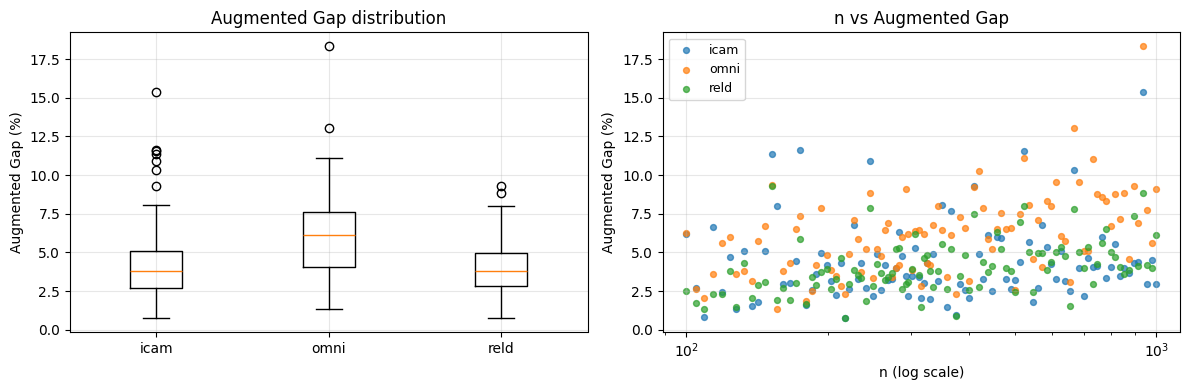

In [18]:
# 8) 可视化（可选）
if plt is None or np is None:
    print("matplotlib/numpy 不可用，跳过绘图")
elif not methods:
    print("no methods")
else:
    data = {m: np.array([run_gap[m][inst] for inst in common_sorted], dtype=float) for m in methods}
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].boxplot([data[m] for m in methods], labels=methods, showfliers=True)
    ax[0].set_title("Augmented Gap distribution")
    ax[0].set_ylabel("Augmented Gap (%)")
    ax[0].grid(True, alpha=0.3)

    if inst_n:
        ns = np.array([inst_n[inst] for inst in common_sorted], dtype=float)
        for m in methods:
            ax[1].scatter(ns, data[m], s=18, alpha=0.7, label=m)
        ax[1].set_xscale("log")
        ax[1].set_title("n vs Augmented Gap")
        ax[1].set_xlabel("n (log scale)")
        ax[1].set_ylabel("Augmented Gap (%)")
        ax[1].grid(True, alpha=0.3)
        ax[1].legend(fontsize=9)
    else:
        ax[1].axis("off")

    plt.tight_layout()
    plt.show()
